In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyranges as pr
import glob as glob
import os
from importlib import reload
%matplotlib inline
import sys
sys.path.append("modules")
import bedgraph_tools as bgt
import peak_tools as pkt
from collections import defaultdict
import pyBigWig as pw
import pysam
from itertools import groupby
from Bio import motifs
import logomaker
from Bio import Align
from Bio.Seq import Seq
%config InlineBackend.figure_format='retina'
import matplotlib
from scipy import stats
from scipy.interpolate import interp1d
matplotlib.rcParams['pdf.fonttype'] = 42
nmeta = pd.read_parquet('metadata/metadata.parquet')
import matplotlib.colors as mcolors
aligner = Align.PairwiseAligner()


/home/labs/barkailab/vovam/miniconda/envs/iran/lib/python3.11/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
def load_and_add_name_col(path, name):
    pp = pr.read_bed(path)
    pp = pp.insert(pd.Series(data = np.char.add(np.arange(len(pp)).astype(str), '_{}'.format(name)), name="Column"))
    return pp

# def load_mot(path):
#     return pd.read_csv(os.path.join(path, 'fimo.tsv'), delimiter='\t').iloc[:-3,: ].loc[:, ['motif_id', 'sequence_name', 'start', 'stop', 'strand']]

def align_mots(ref, seq2, aligner=aligner):
    aligned_F = aligner.align(ref, seq2)
    aligned_R = aligner.align(ref, Seq(seq2).reverse_complement())
    
    if aligned_F.score >= aligned_R.score:
        return "+"
    else:
        return "-"

def load_mot(path, mot_path):
    with open(mot_path) as handle:
        cosensus_mot = motifs.read(handle, "pfm-four-columns").consensus

        # Extract the motif sequences (not specifically used below)
    loaded_loc = pd.read_csv(os.path.join(path, 'fimo.tsv'), delimiter='\t').iloc[:-3,: ]#.loc[:, ['motif_id', 'sequence_name', 'start', 'stop', 'strand', 'matched_sequence']]
    seqs = loaded_loc.sort_values(by='score', ascending=False).loc[:, 'matched_sequence']
#     loaded_loc['strand'] = seqs.apply(lambda x: align_mots(cosensus_mot, x, aligner)).values
    return loaded_loc

def filter_top_quantile(group, quantile=0.9):
    """
    Filters rows in a group where the sum across columns is above the quantile threshold.
    
    Parameters:
        group (pd.DataFrame): Grouped DataFrame.
        quantile (float): The quantile threshold (default 0.9).
        
    Returns:
        pd.DataFrame: Filtered DataFrame with top quantile rows.
    """
    # Compute the sum across all numeric columns per row
    row_sums = group.loc[:, list(np.arange(70,90).astype(str)) + list(np.arange(110,130).astype(str))].sum(axis=1)
    row_sums = group.loc[:, list(np.arange(200).astype(str))].sum(axis=1)

    # Compute the quantile threshold
    threshold = np.quantile(row_sums, quantile)

    # Return rows that exceed the threshold
    return group[row_sums >= threshold]

def find_gap_length(series, threshold):
    """
    Finds the length of the largest gap in the given series where values are below a threshold.

    Parameters:
    series (pd.Series): The mean signal data.
    threshold (float): The value below which the signal is considered absent.

    Returns:
    int: Length of the largest contiguous gap.
    """
    below_threshold = series < threshold  # Boolean mask where values are below the threshold
    gap_lengths = []  # Store lengths of gaps
    current_length = 0

    for is_below in below_threshold:
        if is_below:
            current_length += 1
        else:
            if current_length > 0:
                gap_lengths.append(current_length)
                current_length = 0

    if current_length > 0:  # Catch gap at the end
        gap_lengths.append(current_length)

    return max(gap_lengths, default=0)

def load_and_rename_mot(path, name):
    mot_enrich = pd.DataFrame(pd.read_csv(os.path.join(path, 'fimo.tsv'), delimiter='\t').iloc[:-3].set_index('sequence_name').loc[:, 'score']).reset_index().groupby('sequence_name').count()
    mot_enrich.columns = [name]
    return mot_enrich
def compute_footprint_lengths(x, y, thresholds):
    """
    Compute footprint lengths for multiple percentage thresholds.
    
    Parameters:
        x (array-like): X-values (time or index)
        y (array-like): Y-values (signal intensity)
        thresholds (list): List of percentage drop values (e.g., [0.05, 0.1, 0.5])

    Returns:
        footprint_lengths (dict): Dictionary with thresholds as keys and footprint lengths as values.
    """
    # Interpolation function
    interp_func = interp1d(x, y, kind='linear')

    # Generate more dense x values for interpolation
    window = 600
    x_dense = np.linspace(min(x), max(x), window)
    y_dense = interp_func(x_dense)  # Interpolated y values

    # Find Peak
    peak_index = int(window/2)
    peak_x = x_dense[peak_index]
    peak_y = y_dense[peak_index]

    footprint_lengths = {}

    for threshold in thresholds:
        threshold_value = threshold * peak_y  # Compute threshold level

        # Find left and right drop-off points safely
        left_indices = np.where(y_dense[:peak_index] <= threshold_value)[0]
        right_indices = np.where(y_dense[peak_index:] <= threshold_value)[0]

        left_x = x_dense[left_indices[-1]] if len(left_indices) > 0 else None
        right_x = x_dense[right_indices[0] + peak_index] if len(right_indices) > 0 else None

        # Compute footprint length if both sides exist
        footprint_length = right_x - left_x if left_x is not None and right_x is not None else None

        footprint_lengths[threshold] = footprint_length

    return footprint_lengths
def get_targets_df(data, thresh, t_name,):

    threshed = data>=thresh
    targets = pd.DataFrame(np.where(threshed.values)[0],
    np.where(threshed.values)[1]).reset_index().groupby('index').agg({0:lambda x: list(x)})
    targets.index = data.columns

    numeric_to_name = lambda x: data.iloc[targets.iloc[x].values[0]].sort_values(ascending=False, by=data.columns.values[x]).index.values

    targets.loc[:, t_name] = list(map(numeric_to_name, range(targets.index.shape[0])))
    targets = targets.drop(0, axis=1)
    return targets


In [3]:
os.makedirs('figures/Fig4/', exist_ok=True)

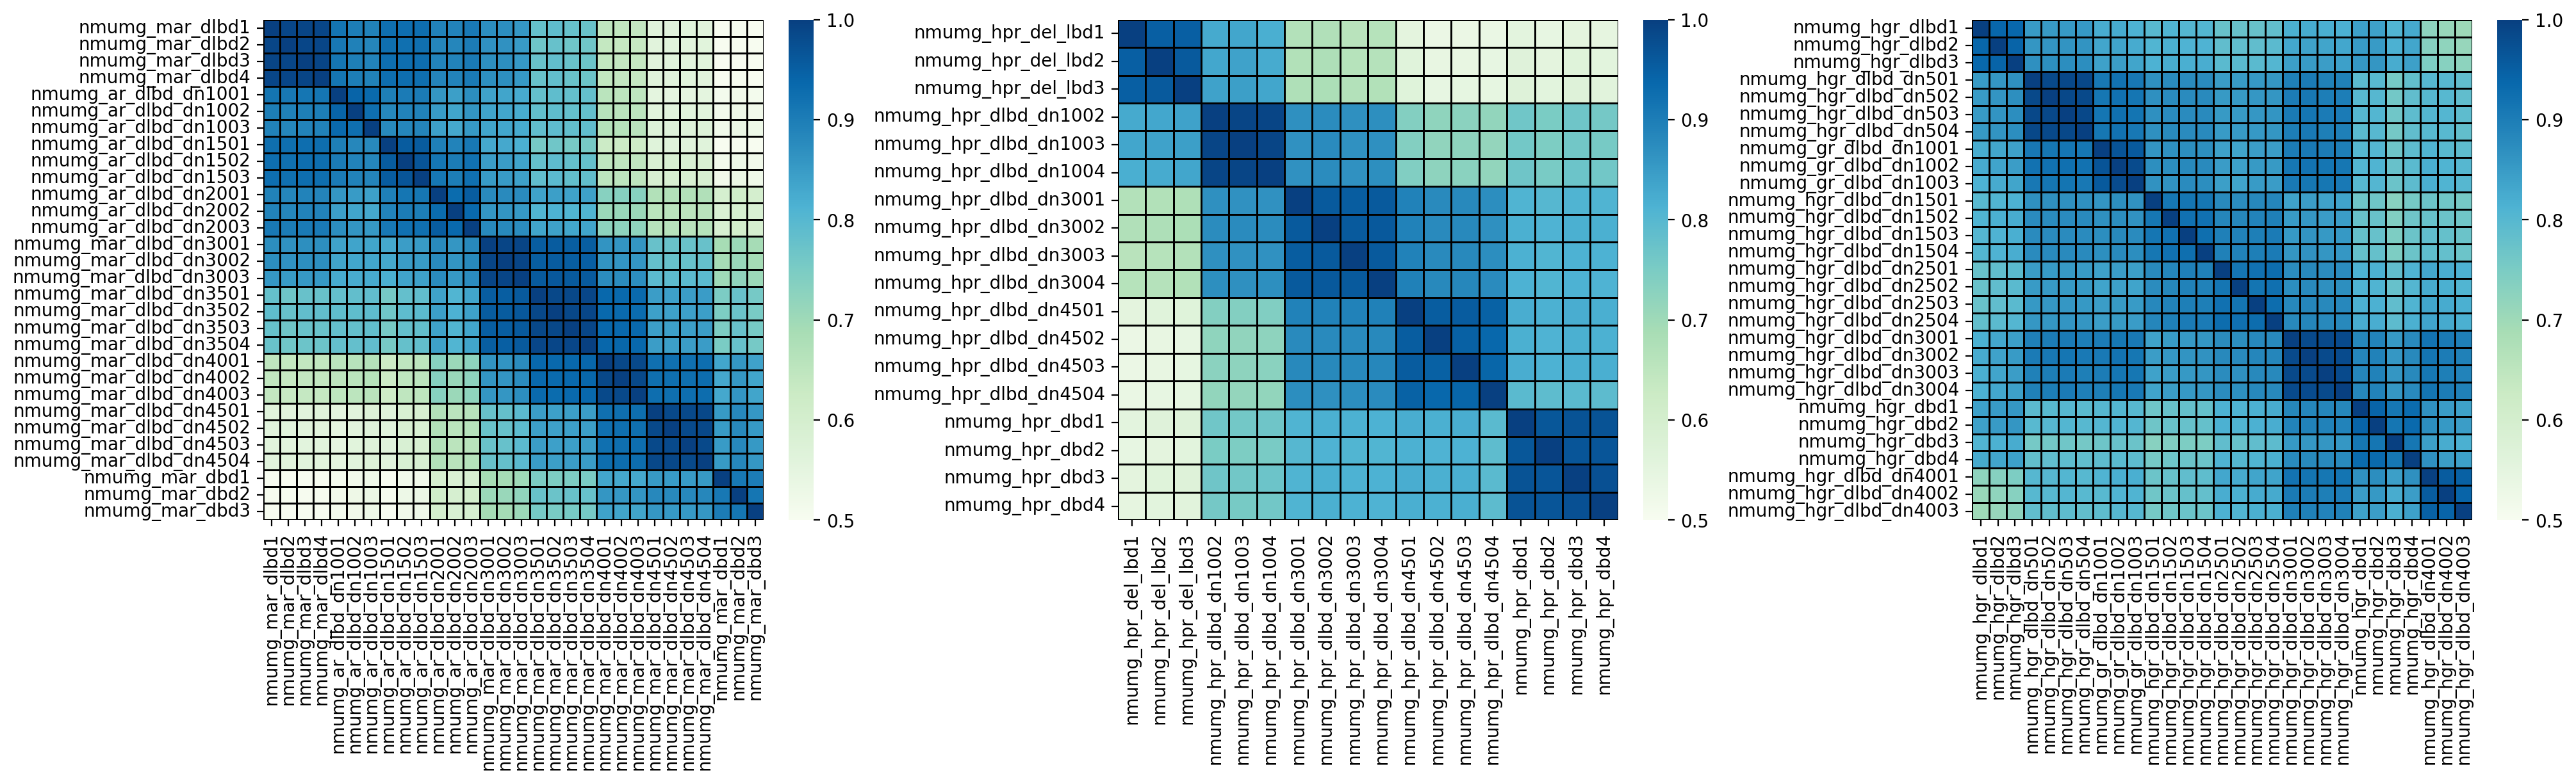

In [4]:
data1 = pd.read_parquet('data/cell_peaks_dbddlbdwtlig/nmumg_sumsig600bp_of_peaks_artruncations_repeats_all.parquet')
scols1 = ['nmumg_mar_dlbd','nmumg_ar_dlbd_dn100', 'nmumg_ar_dlbd_dn150', 'nmumg_ar_dlbd_dn200',
        'nmumg_mar_dlbd_dn300',
       'nmumg_mar_dlbd_dn350', 'nmumg_mar_dlbd_dn400', 'nmumg_mar_dlbd_dn450','nmumg_mar_dbd', ]
d1 = pd.DataFrame()
for i in scols1:
    d1 = pd.concat([d1, data1.filter(regex=i + '[1|2|3|4]')], axis=1)
    
data2 = pd.read_parquet('data/cell_peaks_dbddlbdwtlig/nmumg_sumsig600bp_of_peaks_prtruncations_repeats_all.parquet')
scols2 = ['nmumg_hpr_del_lbd', 'nmumg_hpr_dlbd_dn100',
       'nmumg_hpr_dlbd_dn300', 'nmumg_hpr_dlbd_dn450', 'nmumg_hpr_dbd', ]

d2 = pd.DataFrame()
for i in scols2:
    d2 = pd.concat([d2, data2.filter(regex=i + '[1|2|3|4]')], axis=1) 

data3 = pd.read_parquet('data/cell_peaks_dbddlbdwtlig/nmumg_sumsig600bp_of_peaks_grtruncations_repeats_all.parquet')
scols3 =  ['nmumg_hgr_dlbd', 'nmumg_hgr_dlbd_dn50','nmumg_gr_dlbd_dn100', 
       'nmumg_hgr_dlbd_dn150', 'nmumg_hgr_dlbd_dn250', 'nmumg_hgr_dlbd_dn300','nmumg_hgr_dbd',
       'nmumg_hgr_dlbd_dn400',]
d3 = pd.DataFrame()
for i in scols3:
    d3 = pd.concat([d3, data3.filter(regex=i + '[1|2|3|4]')], axis=1) 
fig, ax = plt.subplots(1,3, figsize=(20,6), constrained_layout=True)
sns.heatmap(d1.corr(), cmap='GnBu', ax=ax[0], linecolor='k', lw=.5, vmin=.5, annot=False, xticklabels=d1.columns, yticklabels=d1.columns)
sns.heatmap(d2.drop('nmumg_hpr_dlbd_dn1001', axis=1).corr(), cmap='GnBu', ax=ax[1], linecolor='k', lw=1, vmin=.5, annot=False, xticklabels=d2.drop('nmumg_hpr_dlbd_dn1001', axis=1).columns, yticklabels=d2.drop('nmumg_hpr_dlbd_dn1001', axis=1).columns)
sns.heatmap(d3.corr(), cmap='GnBu', ax=ax[2], linecolor='k', lw=.5, vmin=.5, annot=False, xticklabels=d3.columns, yticklabels=d3.columns)
fig.savefig('figures/Fig4/4A.pdf')

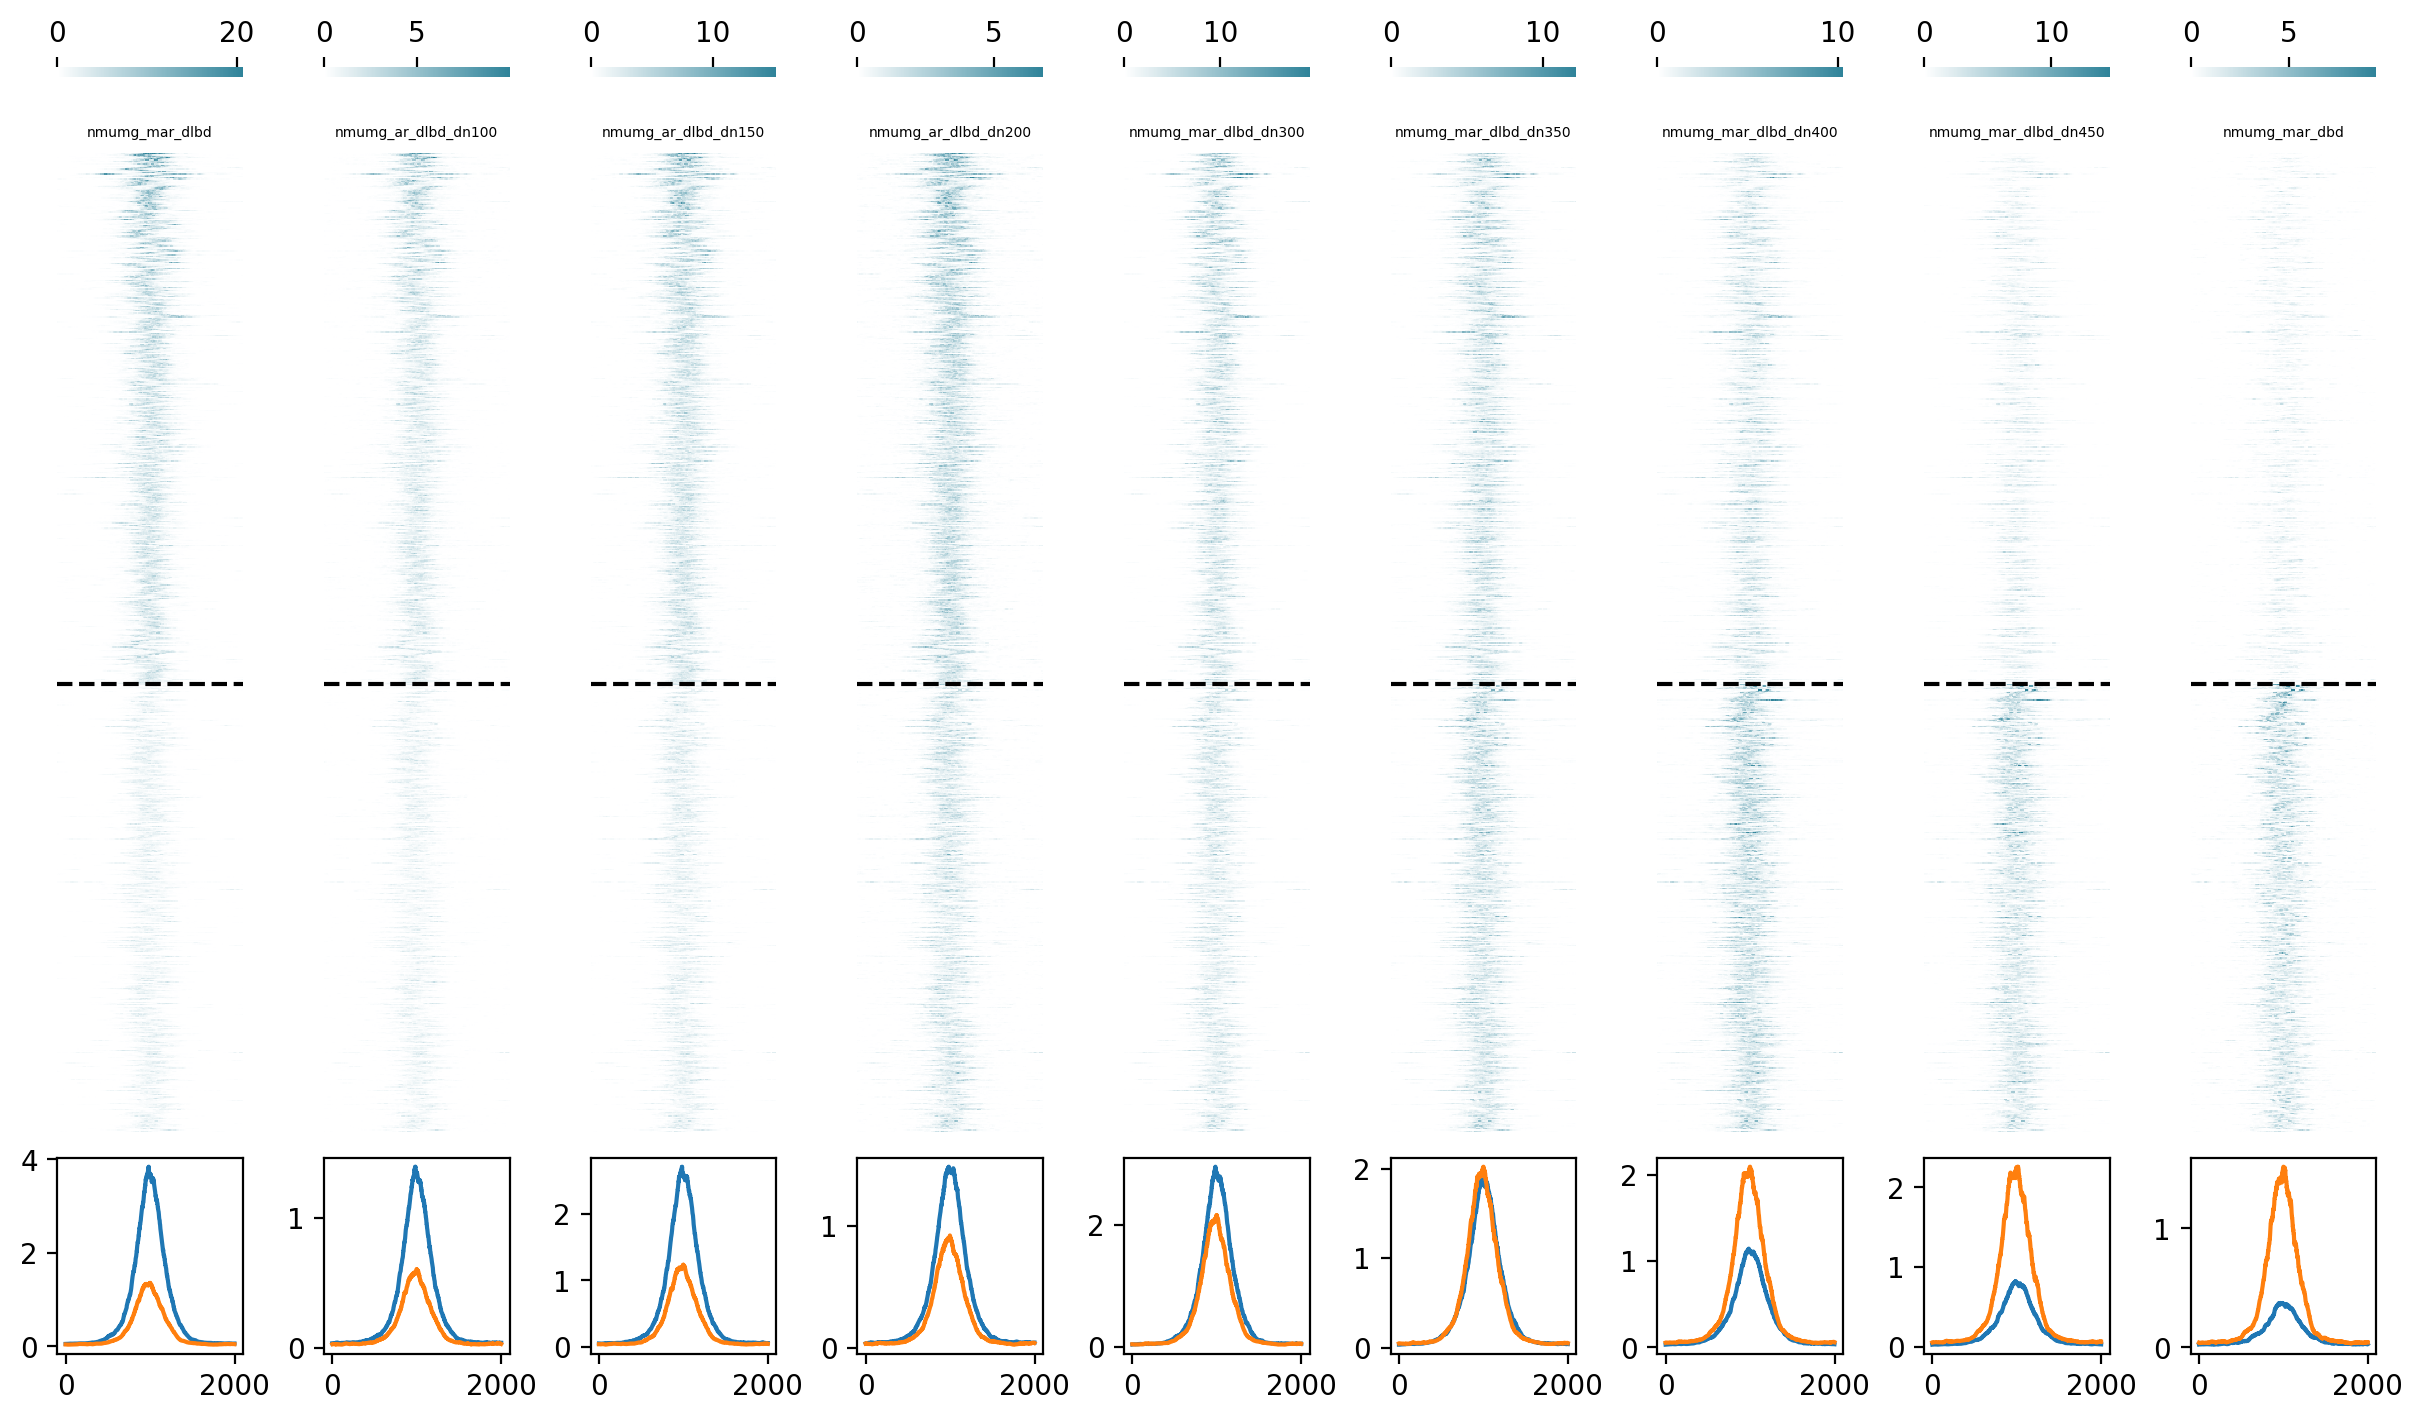

In [15]:
data1 = pd.read_parquet('data/cell_peaks_dbddlbdwtlig/nmumg_ar_trunc_clustered_peak_wsignals.parquet')
z = data1.set_index('nindex').loc[:, scols1]
z = (z-z.mean()) / z.std()
ind = pd.Index(np.concatenate(np.concatenate(get_targets_df(z,3,'a').values))).drop_duplicates()

sigs = ['data/cell_peaks_dbddlbdwtlig/signal_of_peaks_artruncations_nmumg_mar_dlbd.parquet',
    'data/cell_peaks_dbddlbdwtlig/signal_of_peaks_artruncations_nmumg_ar_dlbd_dn100.parquet',
 'data/cell_peaks_dbddlbdwtlig/signal_of_peaks_artruncations_nmumg_ar_dlbd_dn150.parquet',
 'data/cell_peaks_dbddlbdwtlig/signal_of_peaks_artruncations_nmumg_ar_dlbd_dn200.parquet',
 'data/cell_peaks_dbddlbdwtlig/signal_of_peaks_artruncations_nmumg_mar_dlbd_dn300.parquet',
 'data/cell_peaks_dbddlbdwtlig/signal_of_peaks_artruncations_nmumg_mar_dlbd_dn350.parquet',
 'data/cell_peaks_dbddlbdwtlig/signal_of_peaks_artruncations_nmumg_mar_dlbd_dn400.parquet',
 'data/cell_peaks_dbddlbdwtlig/signal_of_peaks_artruncations_nmumg_mar_dlbd_dn450.parquet',
 'data/cell_peaks_dbddlbdwtlig/signal_of_peaks_artruncations_nmumg_mar_dbd.parquet',
]

dl_ind = list(z.query("nmumg_mar_dlbd>3 & nmumg_mar_dbd<2").sort_values(by='nmumg_mar_dlbd', ascending=False).index)
dbd_ind = list(z.query("nmumg_mar_dlbd<2 & nmumg_mar_dbd>=3").sort_values(by='nmumg_mar_dbd', ascending=False).index)
ind =  dl_ind+dbd_ind
     

fig, ax = plt.subplots(2,9, figsize=(12,7), constrained_layout=True, height_ratios=[5,1])
ax=ax.T

sigs_d = dict()

for (axi, axk),sig in zip(ax,sigs):
    sigi = pd.read_parquet(sig)
    name = sig.split('/')[-1].split('artruncations_')[-1].split('.')[0]
    
    vmax = sigi.loc[ind].max().max()*.8
    sns.heatmap(sigi.loc[ind], ax=axi,  cmap=sns.blend_palette(['white', '#056a85'], as_cmap=True),
                vmax=vmax, center=(vmax/2)*1.2, cbar=True, cbar_kws = {'location':'top'}, xticklabels=False, yticklabels=False, rasterized=True)
    axi.axhline(len(dl_ind), c='k', ls='--')
    axi.set_ylabel('')
    name = sig.split('/')[-1].split('.')[0].split('ations_')[1]
    axi.set_title(name, size=5)
    
    dlbdm = sigi.loc[dl_ind].mean()
    dbdm = sigi.loc[dbd_ind].mean()
    sigs_d[name] = {'dlbd':dlbdm, 'dbd':dbdm}
    
    axk.plot(dlbdm)
    axk.plot(dbdm)
fig.savefig('figures/Fig4/4B.pdf')


/tmp/ipykernel_913839/3432056900.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  summits = pd.DataFrame(sigs_d).applymap(lambda x: np.max(x))
/tmp/ipykernel_913839/3432056900.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


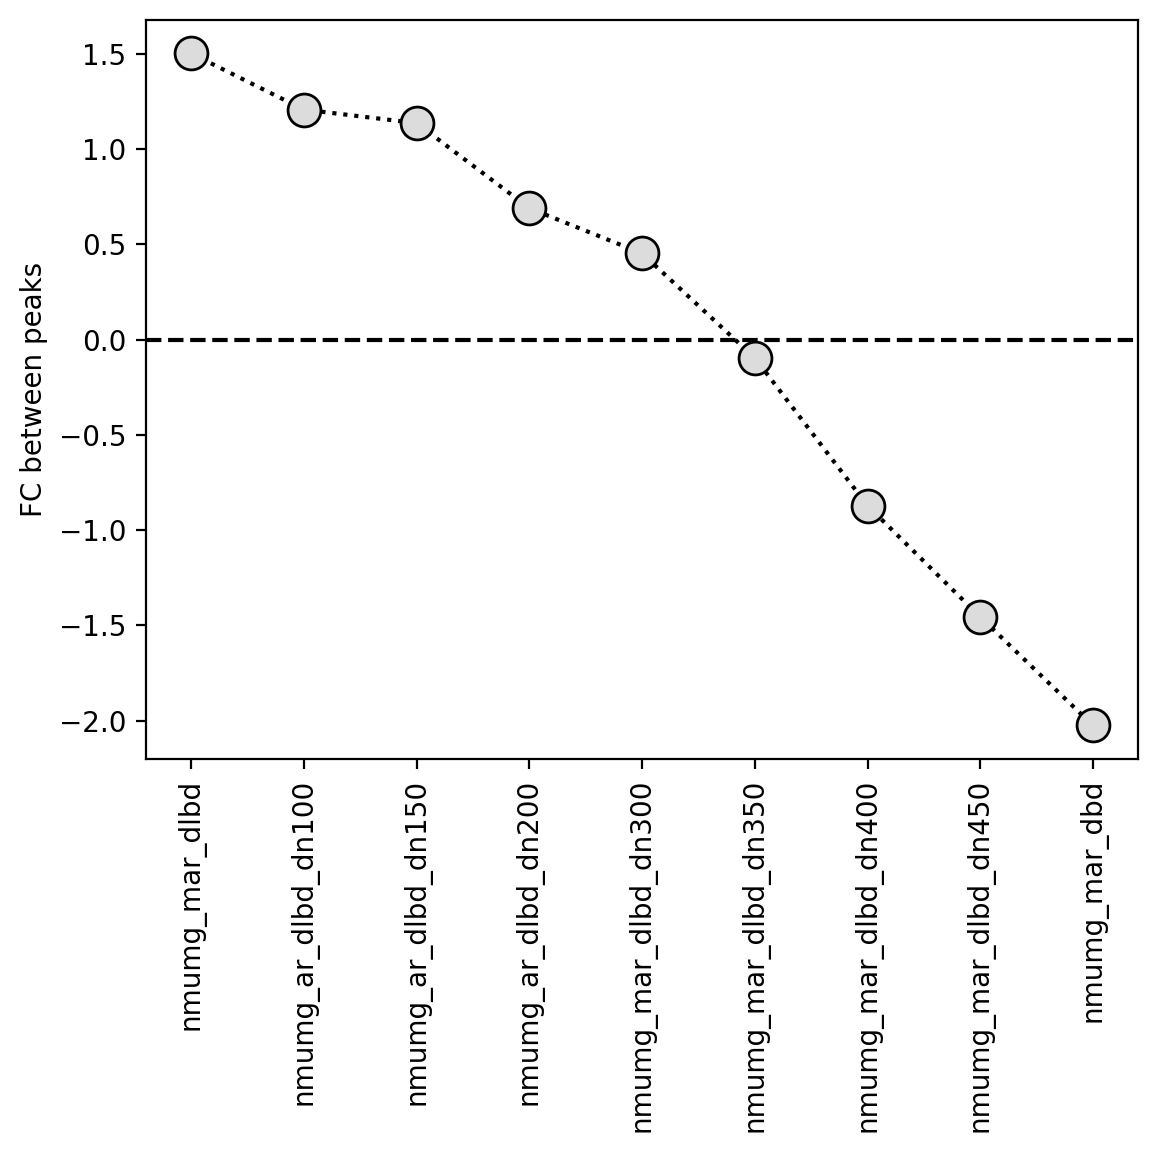

In [7]:
summits = pd.DataFrame(sigs_d).applymap(lambda x: np.max(x))
mpeak_fc = (summits.iloc[0,:] / summits.iloc[1,:])

fig, ax = plt.subplots(1)

ax.scatter(mpeak_fc.index, np.log2(mpeak_fc), s=140, ec='k', c='gainsboro', zorder=20)
ax.plot(mpeak_fc.index, np.log2(mpeak_fc), c='k', ls=':')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.axhline(0, c='k', ls='--')
ax.set_ylabel('FC between peaks')

fig.savefig('figures/Fig4/4C.pdf')
